### Get all time related vectors from BehaviorSync and create some basic comparisons

In [1]:
from scripts.conf_file_finding import try_find_conf_file
try_find_conf_file()


Local configuration file found !!, no need to run the configuration (unless configuration has changed)


In [2]:
import u19_pipeline.ephys_pipeline as ep
import u19_pipeline.recording as recording
import matplotlib.pyplot as plt
import datajoint as dj
 


/mnt/cup/braininit/Shared/repos/TestU19PipelinePython2/U19-pipeline-python/.venv/lib/python3.13/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-28 17:26:48,023][INFO]: DataJoint 0.14.6 connected to alvaros@datajoint00.pni.princeton.edu:3306


#### Select recording_id to fetch from

In [18]:
beh_key = dict()
beh_key['subject_fullname'] = 'emdia_nicky'
beh_key['session_date'] = '2026-03-27'
beh_key['session_number'] = 0
beh_key

{'subject_fullname': 'emdia_nicky',
 'session_date': '2026-03-27',
 'session_number': 0}

### Check if session exists

In [19]:
recording_beh_key = (recording.Recording.BehaviorSession & beh_key).fetch(as_dict=True)

if len(recording_beh_key) == 0:
    print('No recording data found for this session')
elif len(recording_beh_key) > 1:
    print('Multiple recordings for this behavior key, select only one')
elif len(recording_beh_key) == 1:
    recording_key = dict()
    recording_key['recording_id'] = recording_beh_key[0]['recording_id']
    print(recording_key)


{'recording_id': 628}


#### Get behaviorSync and behavior records:

In [22]:

sync_record = (ep.BehaviorSync & recording_key).fetch1('sync_data')
full_sync_record = (ep.BehaviorSync & recording_key).fetch1()

behavior = dj.create_virtual_module('behavior','u19_behavior')
behavior_session = (recording.Recording.BehaviorSession & recording_key).fetch(as_dict=True)[0]
behavior_session.pop('recording_id')
behavior_time = (behavior.SpatialTimeBlobs & behavior_session).fetch(as_dict=True)

behavior_session

{'subject_fullname': 'emdia_nicky',
 'session_date': datetime.date(2026, 3, 27),
 'session_number': 0}

"Old ephys sync variables:
**iteration_index_nidq** & **trial_index_nidq** 
are deprecated now = [nan], use sync_data column now:

In [28]:
full_sync_record

{'recording_id': 628,
 'nidq_sampling_rate': 5000.06,
 'iteration_index_nidq': [nan],
 'trial_index_nidq': [nan],
 'sync_data': {'trial_idx_vector': array([   25842,   108071,   158087,   206693,   249567,   302518,
           345588,   416492,   471990,   526053,   588889,   656780,
           718922,   786097,   856756,   906895,   995002,  1054272,
          1131682,  1193047,  1252102,  1312801,  1373404,  1436470,
          1492929,  1598231,  1675261,  1737718,  1794917,  1888485,
          1977144,  2044740,  2103463,  2155968,  2228857,  2289998,
          2374681,  2474165,  2526672,  2632893,  2724717,  2779532,
          2844366,  2899629,  2987188,  3037776,  3109755,  3178094,
          3232538,  3304437,  3352392,  3415898,  3488007,  3566360,
          3620720,  3695456,  3756231,  3819682,  3882464,  3992580,
          4061024,  4113196,  4191623,  4273659,  4325917,  4403875,
          4463758,  4571827,  4626359,  4690597,  4754745,  4813961,
          4892824,  49823

##### Sync data description:
(using pulse aided syncing)
1. **trial_idx_vector** = nx1 numpy array. Each value of array is starting sample for each trial for each trial in the SpikeGLX full vector
2. **iteration_idx_vector** = nx1 numpy array. Each array is an array with starting sample for each iteration for each trial in the SpikeGLX full vector

(using only ViRMEn time as reference)

3. **trial_idx_vector_from_virmen** = nx1 numpy array. Each value of array is starting sample for each trial for each trial in the SpikeGLX full vector
4. **iteration_idx_vector_from_virmen** = nx1 numpy array. Each array is an array with starting sample for each iteration for each trial in the SpikeGLX full vector

In [29]:
sync_record['trial_idx_vector']

array([   25842,   108071,   158087,   206693,   249567,   302518,
         345588,   416492,   471990,   526053,   588889,   656780,
         718922,   786097,   856756,   906895,   995002,  1054272,
        1131682,  1193047,  1252102,  1312801,  1373404,  1436470,
        1492929,  1598231,  1675261,  1737718,  1794917,  1888485,
        1977144,  2044740,  2103463,  2155968,  2228857,  2289998,
        2374681,  2474165,  2526672,  2632893,  2724717,  2779532,
        2844366,  2899629,  2987188,  3037776,  3109755,  3178094,
        3232538,  3304437,  3352392,  3415898,  3488007,  3566360,
        3620720,  3695456,  3756231,  3819682,  3882464,  3992580,
        4061024,  4113196,  4191623,  4273659,  4325917,  4403875,
        4463758,  4571827,  4626359,  4690597,  4754745,  4813961,
        4892824,  4982396,  5053258,  5128570,  5194119,  5247778,
        5315272,  5368464,  5454133,  5503123,  5568849,  5678969,
        5730219,  5812960,  5876678,  5932050,  5998366,  6056

#### To get "full" vectors (Same size as SpikeGLX recordings) use:
**ephys_pipeline.get_full_vectors_from_key** function

In [30]:
all_vectors = ep.get_full_vectors_from_key(recording_key)

ephys dir: /mnt/cup/braininit/Data/Raw/electrophysiology/emdia/emdia_nicky/20260327_g0/nicky_20260327_g0


In [32]:
all_vectors.keys()

dict_keys(['trial_index_nidq_virmen', 'iteration_index_nidq_virmen', 'trial_index_nidq', 'iteration_index_nidq', 'time_vector', 'time_as_behavior_trial_ind', 'time_as_behavior_fullsession', 'time_as_behavior_trial_ind_virmen', 'time_as_behavior_fullsession_virmen'])

#### Concatenate arrays of arrays vectors to get single vector time variables

In [37]:
import numpy as np
time_as_behavior_fullsession = np.concatenate(([x for x in all_vectors['time_as_behavior_fullsession']]), axis=0) 
time_as_behavior_trial_ind = np.concatenate(([x for x in all_vectors['time_as_behavior_trial_ind']]), axis=0) 



#### Compare behvaior file time variables vs BehaviorSync ones 

In [40]:
diff_time_trial_ind = behavior_time[0]['trial_time'].squeeze() - time_as_behavior_trial_ind
diff_time_trial_full_session = (behavior_time[0]['cumulative_session_time'].squeeze() - behavior_time[0]['cumulative_session_time'][0]) - time_as_behavior_fullsession


#### "pulse only sync" single vector time for all session [0, ...] x 1
#### Compare nidaq signal for behavior iteration "start time".

Text(0.5, 1.0, 'iteration "start time" comparison -- behavior file - nidaq pulse signal. Single vector time all session')

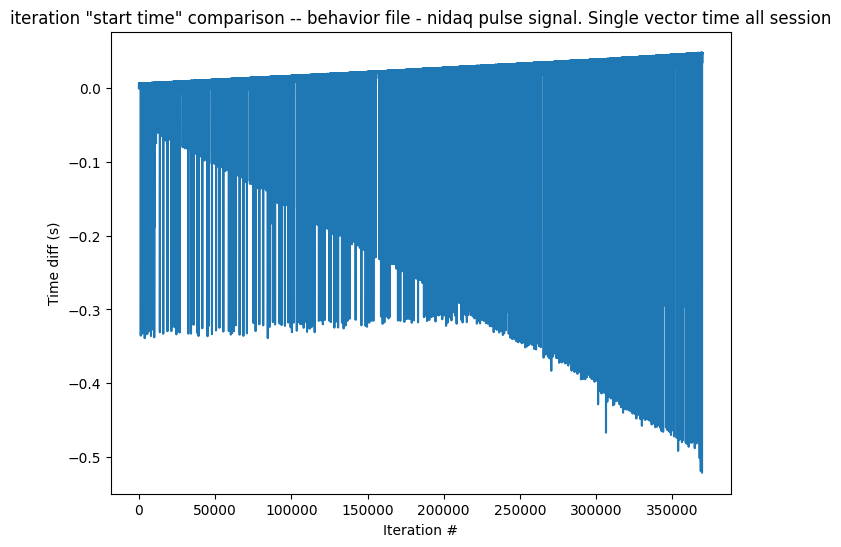

In [41]:
plt.figure(figsize=(8, 6))
plt.plot(diff_time_trial_full_session)

plt.xlabel('Iteration #')
plt.ylabel('Time diff (s)')
plt.title('iteration "start time" comparison -- behavior file - nidaq pulse signal. Single vector time all session')

Text(0.5, 1.0, 'iteration "start time" Histogram -- behavior file - nidaq pulse signal. Single vector time all session')

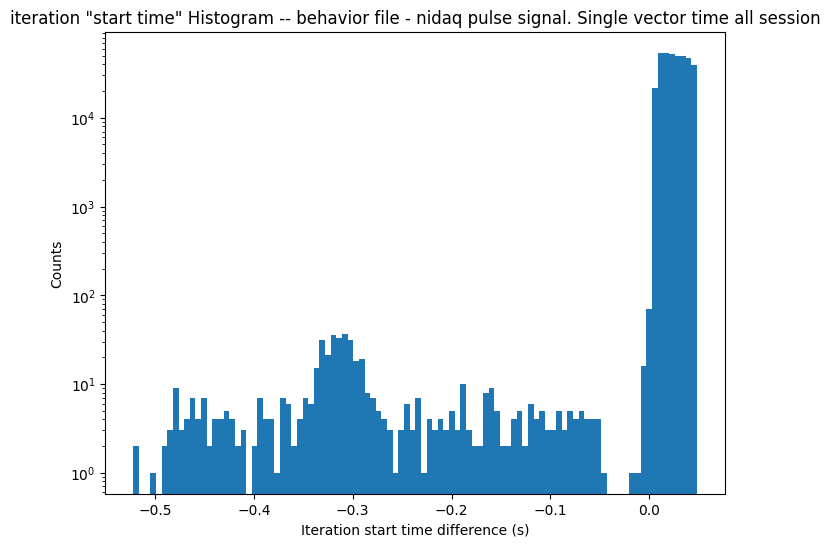

In [42]:
plt.figure(figsize=(8, 6))

plt.hist(diff_time_trial_full_session,bins=100)

plt.yscale('log')
plt.xlabel('Iteration start time difference (s)')
plt.ylabel('Counts')
plt.title('iteration "start time" Histogram -- behavior file - nidaq pulse signal. Single vector time all session')

